In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Create synthetic data points
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=1000, n_features=2,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1)

In [ ]:
#Converting X into dataframe
pd.DataFrame(X)

,0,1
0,0.828542,1.198058
1,-1.040739,-0.660620
2,-2.636403,0.690350
3,0.195832,-2.180741
4,0.900594,1.036961
...,...,...
995,0.485567,0.795215
996,0.389067,-3.342994
997,0.536656,0.855723
998,0.307066,0.420925


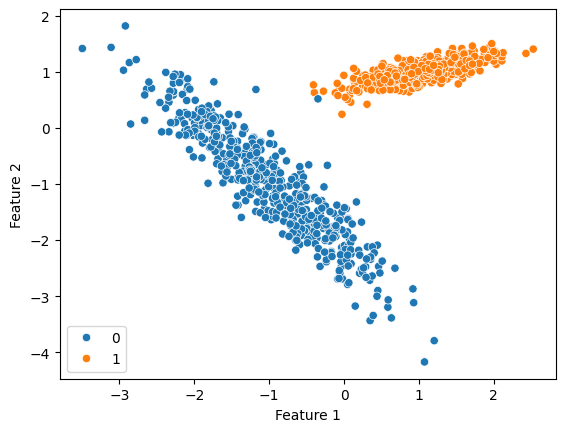

In [ ]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)
#hue=y represents datapoints with different colours based on output feature
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

In [ ]:
from sklearn.svm import SVC
svc=SVC(kernel='linear')      #as our data points are clearly seperable so we use a liner kernel
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [ ]:
#Predicting from test i/p data
y_pred=svc.predict(X_test)

In [ ]:
#Performance metrics
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.996
[[130   1]
 [  0 119]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       131
           1       0.99      1.00      1.00       119

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



Doing the same for an overlapping dataset

In [ ]:
X,y = make_classification(n_samples=1000, n_features=2,n_redundant=0,
                           n_classes=2, n_clusters_per_class=2)

<Axes: xlabel='0', ylabel='1'>

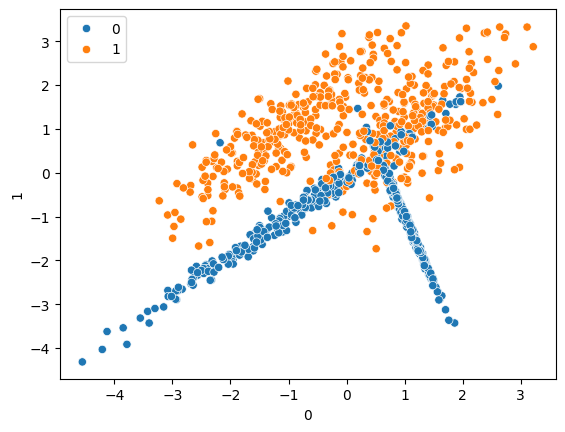

In [ ]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)
rbf=SVC(kernel='rbf')      #as our data points are overlapping so we use a rbf kernel
rbf.fit(X_train,y_train)

SVC()

In [ ]:
y_pred1=rbf.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))

0.864
[[112  11]
 [ 23 104]]
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       123
           1       0.90      0.82      0.86       127

    accuracy                           0.86       250
   macro avg       0.87      0.86      0.86       250
weighted avg       0.87      0.86      0.86       250



In [ ]:
svc=SVC(kernel='linear')      #just testing with linear kernel
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [ ]:
y_pred2=svc.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(classification_report(y_test,y_pred2))

0.864
[[112  11]
 [ 23 104]]
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       123
           1       0.90      0.82      0.86       127

    accuracy                           0.86       250
   macro avg       0.87      0.86      0.86       250
weighted avg       0.87      0.86      0.86       250



In [ ]:
poly=SVC(kernel='poly')      #just testing with polynomial kernel
poly.fit(X_train,y_train)

SVC(kernel='poly')

In [ ]:
y_pred3=poly.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(classification_report(y_test,y_pred3))

0.832
[[118   5]
 [ 37  90]]
              precision    recall  f1-score   support

           0       0.76      0.96      0.85       123
           1       0.95      0.71      0.81       127

    accuracy                           0.83       250
   macro avg       0.85      0.83      0.83       250
weighted avg       0.86      0.83      0.83       250



In [ ]:
sigmoid=SVC(kernel='sigmoid')      #just testing with sigmoid kernel
sigmoid.fit(X_train,y_train)

SVC(kernel='sigmoid')

In [ ]:
y_pred4=sigmoid.predict(X_test)
print(accuracy_score(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))
print(classification_report(y_test,y_pred4))

0.736
[[94 29]
 [37 90]]
              precision    recall  f1-score   support

           0       0.72      0.76      0.74       123
           1       0.76      0.71      0.73       127

    accuracy                           0.74       250
   macro avg       0.74      0.74      0.74       250
weighted avg       0.74      0.74      0.74       250



Thus based on the accuracy score for each type of kernel, we can say that either rbf or linear kernel can be used for the 2nd dataset

#HyperParameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

#Parameter range defining
param_grid = {'C':[0.1,1,10,100,1000],
              'gamma':[1,0.1,0.01,0.001,0.0001],
              'kernel':['rbf']}
#low gamma means train data has far reaching effect but high gamma is opp.
#gamma not used for linear kernel

#GridSearchCV
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3, cv=5)   #verbose prints the progress of cv fitting
grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.887 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.853 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.893 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.873 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.913 total time=   0.1s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.893 total time=   0.1s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.853 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.873 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.873 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.913 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.867 total time=   0.1s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [ ]:
grid.best_params_

{'C': 1000, 'gamma': 1, 'kernel': 'rbf'}

In [ ]:
y_pred5=grid.predict(X_test)
print(accuracy_score(y_test,y_pred5))
print(confusion_matrix(y_test,y_pred5))
print(classification_report(y_test,y_pred5))

0.88
[[111  12]
 [ 18 109]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       123
           1       0.90      0.86      0.88       127

    accuracy                           0.88       250
   macro avg       0.88      0.88      0.88       250
weighted avg       0.88      0.88      0.88       250



Thus we see after hypertuning with kernel=rbf, model's accuracy increased from 86 to 88